# Statistical analysis of water discharge of surface streams

### Task:
* find a dataset about a river's water level
* analyse the various timeseries data by fitting the right/suitable distribution onto it.
* draw some conclusions about the weather near the river/measurement station



### A list of statistical distributions
Fermi-Dirac statistics, Bose-Einstein statistics, Maxwell-Boltzmann distribution, Planck’s law
Binomial distribution
* number of successes of n independent experiments
Cauchy distribution
* ration of normally distributed variables
* shape of spectral lines
Gamma distribution
Geometric distribution
* number of trials before the first success in Bernoulli trials
Chi-squared distribution
* sum of squares of independent standard normal variables
* how to construct confidence intervals
 
Exponential distribution
Gumbel distribution
* expectation value of the maximum/minimum of samples drawn from a parent distribution with exp tail
* Lévy distribution
* heavy-tailed distribution

Logistic distribution
 
* categorical dependent variables
* logistic regression
 
Log normal distribution
 
* product of many independent variables
* size distribution of particles
 
Normal distribution
 
Pareto distribution
* heavy-tailed, decreasing power-law
* degree distribution of social networks
 
Poisson distribution
 
Student t
 
* average of a normally distributed population
* n is small
Uniform distribution
Weibull distribution
 * any of n iid variables being above a certain limit
* first failure of a system of n identical components

## Excercise 1

For the purposes of the current excercises, select a stream from a rainy area with relatively small discharge so that the effect of short but strong storms is visible. Good choices are small rivers from the north-eastern US, e.g. site 01589440. First experiment with a smaller dataset, for example one year long series, but at the end **retrieve at least 10 years of data**.

Large amounts of historical surface water data are available from the United States Geological Survey (USGS) at https://waterdata.usgs.gov/nwis The goal of the project is to retrieve samples from the web interface manually, and then later  automate the process by calling the web service as described at https://help.waterdata.usgs.gov/faq/automated-retrievals.

The service is explained in more detail here: https://waterservices.usgs.gov/docs/site-service/site-service-details/.
#### or

Find a database of historic water level measurement of a large river such as the Danube at Budapest!

In [1]:
import pandas as pd
import os
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
import numpy as np

In [49]:
import requests

# Define the URL for the USGS API
url = "https://nwis.waterdata.usgs.gov/nwis/uv/"

# Define the parameters for the request
params = {
    "format": "rdb",
    "site_no": "01589440",
    "parameterCd": "00065",  # Water level parameter code
    "begin_date" : "20090101",
    "end_date" : "20191231",
    "siteStatus": "all"
}

# Send the GET request
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    # Extract the data from the response
    data = response.text
    # Process the data as needed
    # ...
else:
    print("Error: Failed to retrieve data from the USGS server.")
    print("Status code:", response.status_code)
    print()


In [50]:
!ls /v/courses/2025-202425adatexplorcisvizualizci.assignments/

Application		   Networks		    SQL
Image_Exploration	   NLP			    Timeseries
InteractiveVisualizations  Shapes-Maps-Coordinates


In [51]:
dirname = f"/v/courses/2025-202425adatexplorcisvizualizci.assignments/Timeseries/"

In [52]:
with open(dirname+"water_level_data.txt", "w") as file:
    file.write(data)

In [53]:
#load water_level_data.txt into a pandas dataframe, use dateime as date column, treat comments with "#", skiprow 30, and use tab as delimiter
import pandas as pd

# Load the data into a DataFrame
df = pd.read_csv(dirname+"water_level_data.txt", comment="#", skiprows=[30], parse_dates=["datetime"], delimiter="\t")

# Display the DataFrame
df.head()


/tmp/ipykernel_122/3598282205.py:5: DtypeWarning: Columns (1,4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dirname+"water_level_data.txt", comment="#", skiprows=[30], parse_dates=["datetime"], delimiter="\t")
/tmp/ipykernel_122/3598282205.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(dirname+"water_level_data.txt", comment="#", skiprows=[30], parse_dates=["datetime"], delimiter="\t")


,agency_cd,site_no,datetime,tz_cd,69744_00060,69744_00060_cd,69745_00065,69745_00065_cd
0,5s,15s,20d,6s,14n,10s,14n,10s
1,USGS,01589440,2009-01-01 00:00,EST,NaN,NaN,3.67,A
2,USGS,01589440,2009-01-01 00:15,EST,NaN,NaN,3.66,A
3,USGS,01589440,2009-01-01 00:45,EST,NaN,NaN,3.67,A
4,USGS,01589440,2009-01-01 01:00,EST,NaN,NaN,3.67,A


In [54]:
#use the loaded df DataFrame and rename columns 69744_00060 and 69745_00065 to water_discharge and gage_height, respectively
df = df.rename(columns={'69744_00060': 'water_discharge', '69745_00065': 'gage_height'})


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382595 entries, 0 to 382594
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   agency_cd        382595 non-null  object
 1   site_no          382595 non-null  object
 2   datetime         382595 non-null  object
 3   tz_cd            382595 non-null  object
 4   water_discharge  366517 non-null  object
 5   69744_00060_cd   366517 non-null  object
 6   gage_height      382569 non-null  object
 7   69745_00065_cd   382569 non-null  object
dtypes: object(8)
memory usage: 23.4+ MB


## Excercise 2

Load the downloaded data file into the processing environment paying attention to handling time stamps and perfoming the necessary data type conversions (converting dates to floating point numbers such as unix time stamp or julian date sometimes makes handling time series easier). Plot the data for a certain interval to show that the effect of storms is clearly visible!

In [56]:
import datetime

In [57]:
df.datetime

0                      20d
1         2009-01-01 00:00
2         2009-01-01 00:15
3         2009-01-01 00:45
4         2009-01-01 01:00
                ...       
382590    2019-12-31 22:45
382591    2019-12-31 23:00
382592    2019-12-31 23:15
382593    2019-12-31 23:30
382594    2019-12-31 23:45
Name: datetime, Length: 382595, dtype: object

In [58]:
fmt ="%Y-%m-%d %H:%M"
datatimes = []
water_discharge = []
for i in range(1,df.shape[0]):
    datatimes.append(datetime.datetime.strptime(df['datetime'][i],fmt))
    water_discharge.append(float(df['water_discharge'][i]))

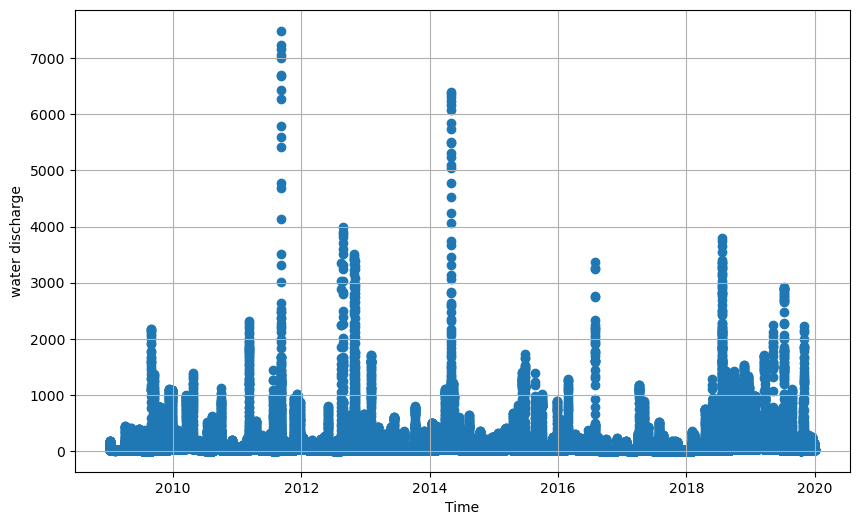

In [59]:
plt.figure(figsize=(10,6))
plt.scatter(datatimes,water_discharge)
plt.xlabel("Time")
plt.ylabel("water discharge")
plt.grid()

## Excercise 3

Plot the histogram of water discharge values. Fit the data with an appropriate distribution function and bring arguments in favor of the choice of function!

In [60]:
df.dtypes

agency_cd          object
site_no            object
datetime           object
tz_cd              object
water_discharge    object
69744_00060_cd     object
gage_height        object
69745_00065_cd     object
dtype: object

In [61]:
df['water_discharge'] = df['water_discharge'][1:].astype('float')

source for the code below .I did share this link with at least one person. https://mode.com/example-gallery/python_histogram 

In [62]:
from numpy import random


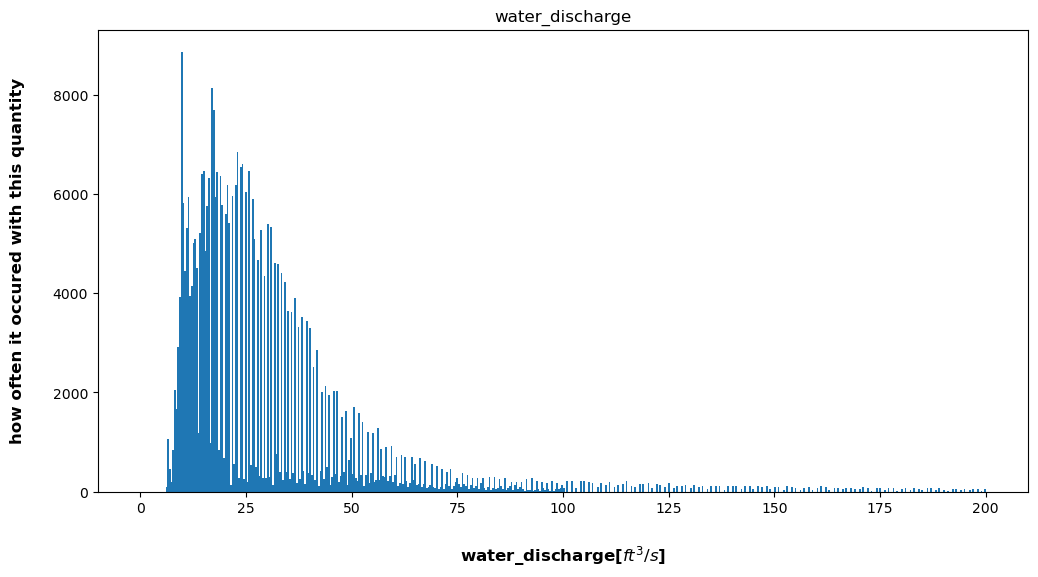

In [63]:
ax = df.hist(column='water_discharge', bins=500, grid=False, figsize=(12,6), rwidth=9,range=(0,200))
ax = ax[0]
for x in ax:
    x.set_xlabel("water_discharge[$ft^{3}/s$]", labelpad=20, weight='bold', size=12)
    x.set_ylabel("how often it occured with this quantity", labelpad=20, weight='bold', size=12)


according to wikipedia "in probability theory and statistics, the Poisson distribution is a discrete probability distribution that expresses the probability of a given number of events occurring in a fixed interval of time if these events occur with a known constant mean rate and independently of the time since the last event". While the weather is not independent of its past( the weather in fact is a chaos system, and its first approximation is the Lorentz system(https://en.wikipedia.org/wiki/Lorenz_system)) I think Poisson distribution is quite a good approximation for the data I have here.

In [64]:
from scipy.optimize import curve_fit
from scipy.special import factorial
from scipy.stats import poisson

entries, bin_edges, patches = plt.hist(df['water_discharge'][1:], bins=1000, density=True, label='water_discharge')
guess=np.mean(df['water_discharge'][1:])
poissondata = poisson.pmf(df['water_discharge'][1:], mu = guess)
plt.plot(poissondata)

plt.plot(
    np.arange(0,69785,guess),
    fit_function(),
    marker='o', linestyle='',
    label='Fit result',
)
plt.xlim(0, 200)

plt.legend()
plt.show()

## Excercise 4

In case of small streams, storms and passing weather fronts with rain can significantly increase water discharge on a short time scale. Develop a simple algorithm to detect rainy events in the data. Plot the original time series and mark rainy events!

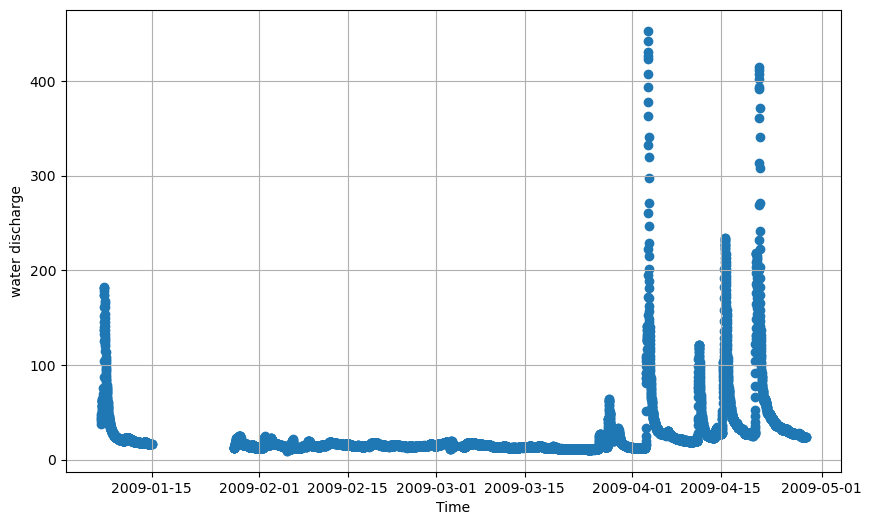

In [65]:
plt.figure(figsize=(10,6))
plt.scatter(datatimes[0:10000],water_discharge[0:10000])
plt.xlabel("Time")
plt.ylabel("water discharge")
plt.grid()

In [66]:
def rain(datatime,water_discharge):
    timedata = []
    waterdata = []
    mean = np.mean(df['water_discharge'][1:])# I use the whole data becouse the mean of a dry section would be really low
    for time in range(0,len(water_discharge)-1):
        if water_discharge[time] > 2*mean: # 2 times mean, becouse from what I experienced it is neccesary.
            timedata.append(datatime[time])
            waterdata.append(water_discharge[time])
    return(timedata,waterdata)
            
        

In [67]:
def rainplot(my_rangemin,my_rangemax):
    plt.figure(figsize=(10,6))
    plt.scatter(datatimes[my_rangemin:my_rangemax],water_discharge[my_rangemin:my_rangemax],linewidths=4,label = "data of water_discharge")
    plt.scatter(rain(datatimes[my_rangemin:my_rangemax],water_discharge[my_rangemin:my_rangemax])[0],rain(datatimes[my_rangemin:my_rangemax],water_discharge[my_rangemin:my_rangemax])[1],linewidths=0.005,label = "assumed rain")
    plt.xlabel("Time")
    plt.ylabel("water discharge")
    plt.legend()
    plt.grid()

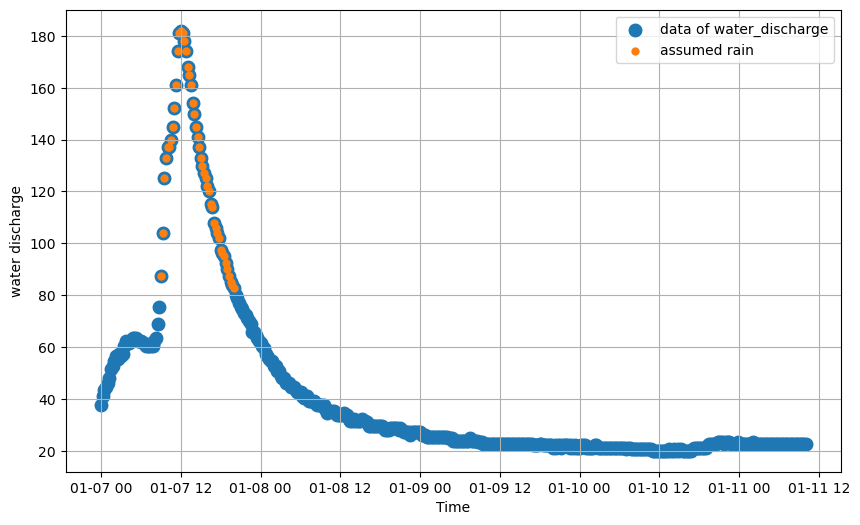

In [68]:
rainplot(0,1000)

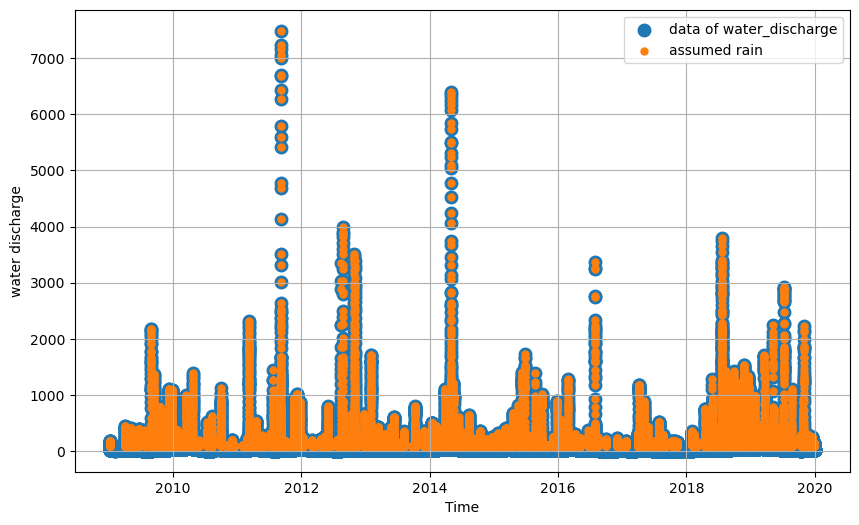

In [69]:
rainplot(0,len(datatimes))

# code explaining
with def Rain I wanted to sort out the rainy times. I did this by comparing the water discharge values to the mean value. if it is more, then it rained. Of course it is not always accurate, becouse for example if it rained upstream but not at the station, the water discharge level does not accuratly represents the weather. 

## Excercise 5

Water discharge increases significantly during rain producing maxima in the time series. Plot the distribution of maximum values and fit with an appropriate function. Bring arguments to support the choice of probabilistic model!

In [70]:
def rainy_times(datatimes,water_discharge):
    mytime = rain(datatimes,water_discharge)[0]
    difference = np.diff(mytime)
    my_mean = np.mean(difference)
    my_times = []
    my_timeineed = []
    for i in range(len(difference)):
        if difference[i] > my_mean:
            my_times.append(mytime[i])
    for j in range(len(my_times)):
        my_timeineed.append(datatimes.index(my_times[j]))
    return(my_timeineed)

In [71]:
def max_search(datatimes,water_discharge):
    indices = rainy_times(datatimes,water_discharge)
    my_maxtimes = []
    my_maxwater = []
    for index in range(1,len(indices)-1):
        max_rain = np.nanmax(water_discharge[indices[index]:indices[index+1]])
        my_index = water_discharge.index(max_rain,indices[index],indices[index+1])
        my_maxwater.append(water_discharge[my_index])
        my_maxtimes.append(datatimes[my_index])
    return(my_maxtimes,my_maxwater)

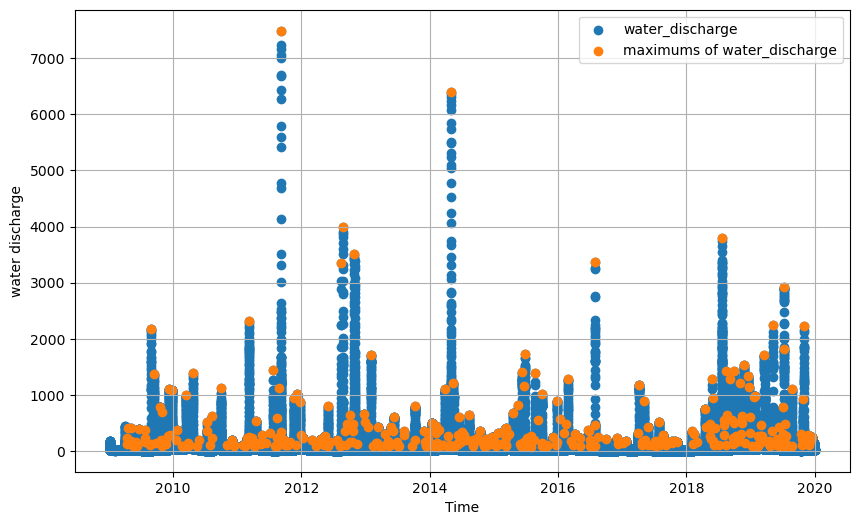

In [72]:
plt.figure(figsize=(10,6))
plt.scatter(datatimes,water_discharge,label="water_discharge")
plt.scatter(max_search(datatimes,water_discharge)[0],max_search(datatimes,water_discharge)[1],label="maximums of water_discharge")
plt.xlabel("Time")
plt.ylabel("water discharge")
plt.grid()
plt.legend()

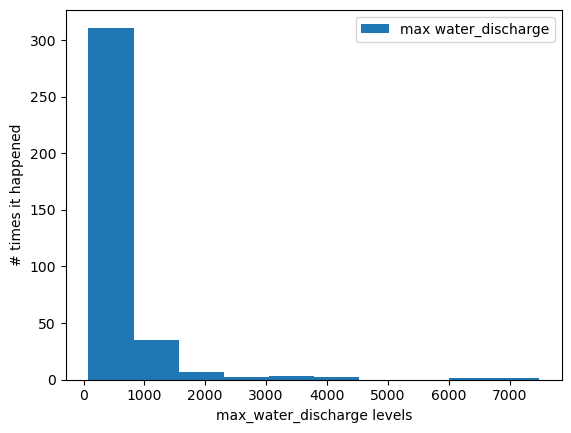

In [73]:
counts, bins = np.histogram(max_search(datatimes,water_discharge)[1])
plt.hist(bins[:-1], bins, weights=counts,label="max water_discharge")
plt.xlabel('max_water_discharge levels')
plt.ylabel('# times it happened')
plt.legend()

# tought process for the code
with rainytimes I selected the times when it rained. I did this by checking the difference in times I selected with the code above(rain), and checking whether the time data is closely next to it, or not. what I selected is the indices of the original data, where the rain times skip. With this I have the "timestamps" of the different reany "season". With max_search I just simply searched for the maximum value between theese "timestamps". As we can see, the result is not perfect. The reason is simple, I expect a perfect data for the code, which is not the case. I could simply say that values below x does not count, but it would also delete little rains, which would compromise the result.

## Excercise 6

Once rainy events are detected, plot the distribution of the length of sunny intervals between rains. Fit the distribution with an appropriate function!

In [74]:
def norain(datatime,water_discharge):
    timedata = []
    waterdata = []
    mean = np.mean(df['water_discharge'][1:])# I use the whole data becouse the mean of a dry section would be really low
    for time in range(0,len(water_discharge)-1):
        if water_discharge[time] < 2*mean:
            timedata.append(datatime[time])
            waterdata.append(water_discharge[time])
    return(timedata,waterdata)
            

In [81]:
def norainplot(my_rangemin,my_rangemax):
    plt.figure(figsize=(10,6))
    plt.scatter(datatimes[my_rangemin:my_rangemax],water_discharge[my_rangemin:my_rangemax],linewidths=4,label = "data of water_discharge")
    plt.scatter(norain(datatimes[my_rangemin:my_rangemax],water_discharge[my_rangemin:my_rangemax])[0],norain(datatimes[my_rangemin:my_rangemax],water_discharge[my_rangemin:my_rangemax])[1],linewidths=0.005,label = "assumed no-rain time")
    plt.xlabel("Time")
    plt.ylabel("water discharge")
    plt.legend()
    plt.grid()

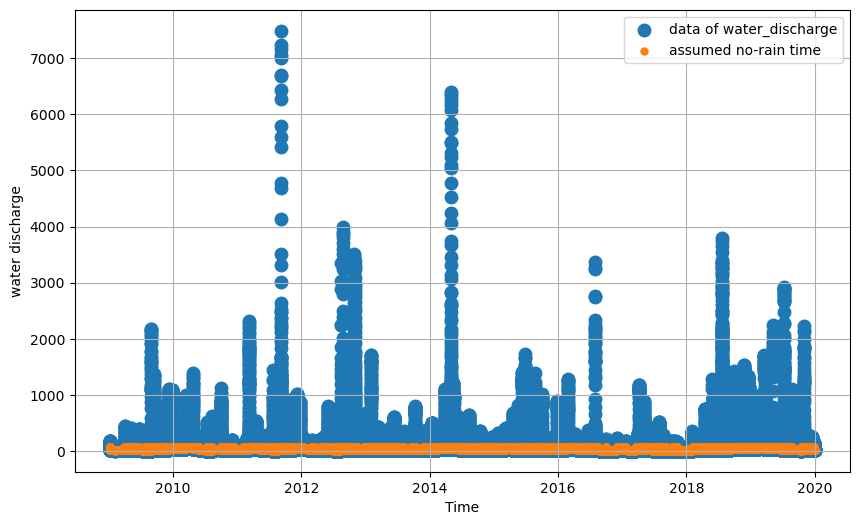

In [82]:
norainplot(0,len(datatimes))

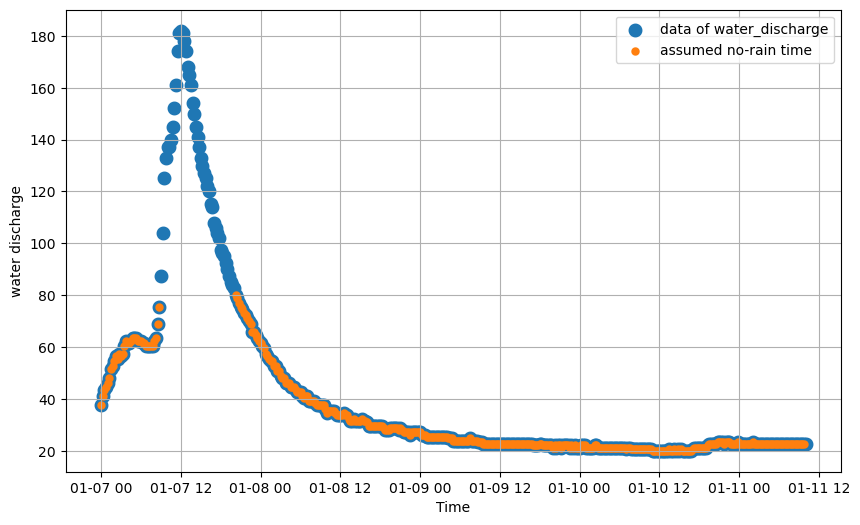

In [77]:
norainplot(0,1000)

In [78]:
def norainy_times(datatimes,water_discharge):
    mytime = norain(datatimes,water_discharge)[0]
    difference = np.diff(mytime)
    my_mean = np.mean(difference)
    my_times = []
    my_timeineed = []
    for i in range(len(difference)):
        if difference[i] > my_mean:
            my_times.append(mytime[i])
    for j in range(len(my_times)):
        my_timeineed.append(datatimes.index(my_times[j]))
    return(my_timeineed)

In [79]:
indices = norainy_times(datatimes,water_discharge)
drylenght = np.diff(indices)

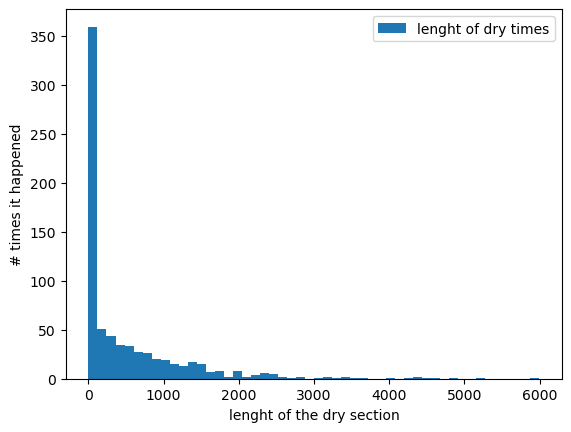

In [80]:
counts, bins = np.histogram(drylenght,bins = 50)
plt.hist(bins[:-1], bins, weights=counts,label="lenght of dry times")
plt.xlabel('lenght of the dry section')
plt.ylabel('# times it happened')
plt.legend()


## Excercise 7

What is the maximum of water discharge in an arbitrarily chosen period of one year? Calculate the maximum of water discharge due to rain in a rolling window of 1 year, plot its distribution and fit with an appropriate function!

df = pd.read_csv(dirname+"water_level_data.txt", comment="#" , skiprows=[30] , parse_dates =["datetime"], delimiter="\t" , index_col ="datetime")
#dirname+"water_level_data.txt", comment="#", skiprows=[30], parse_dates=["datetime"], delimiter="\t"

## Excercise 8

How many time does it rain in a month? (Again use a rolling window function) Calculate and plot the distribution and fit with an appropriate function!

## Excercise 9

Find the measuring station you used in the excercises above on the map. Find another measurement station about 100-200 kms from it and download the data! Try to estimate the typical time it takes for weather fronts to travel the distance between the two measuring stations!